In [3]:
from pyspark.sql import SparkSession
import sys
import os

In [4]:
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .master("local[*]")    
    .getOrCreate()
)

In [5]:
df_train = spark.read.csv("data/train/train.csv", header=True, inferSchema=True)
df_test = spark.read.csv("data/test/test.csv", header=True, inferSchema=True)

In [6]:
df_train.show(5)

+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|       id|vendor_id|    pickup_datetime|   dropoff_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|
+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id2875421|        2|2016-03-14 17:24:55|2016-03-14 17:32:30|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|
|id2377394|        1|2016-06-12 00:43:35|2016-06-12 00:54:38|              1|-73.98041534423828|40.738563537597656|-73.99948120117188| 40.73115158081055|                 N|          663|
|id3858529|        2|2016-01-19 11:35:24|2016-01-19 12:10:48|    

In [7]:
df_test.show(5)

+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|
+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+
|id3004672|        1|2016-06-30 23:59:58|              1|-73.98812866210938|40.73202896118164|-73.99017333984375| 40.75667953491211|                 N|
|id3505355|        1|2016-06-30 23:59:53|              1|-73.96420288085938|40.67999267578125|-73.95980834960938| 40.65540313720703|                 N|
|id1217141|        1|2016-06-30 23:59:47|              1| -73.9974365234375|40.73758316040039|-73.98616027832031|40.729522705078125|                 N|
|id2150126|        2|2016-06-30 23:59:41|              1|-73.95606994628906|40.771900177

In [8]:
print("Train: ", df_train.count(), len(df_train.columns))
print("Test: ", df_test.count(), len(df_test.columns))

Train:  1458644 11
Test:  625134 9


In [9]:
df_train.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'dropoff_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'trip_duration']

In [10]:
df_test.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag']

In [11]:
df_train.printSchema()

root
 |-- id: string (nullable = true)
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- trip_duration: integer (nullable = true)



In [12]:
df_test.printSchema()

root
 |-- id: string (nullable = true)
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)



In [13]:
df_train.summary().show()

+-------+---------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+------------------+
|summary|       id|          vendor_id|   passenger_count|   pickup_longitude|     pickup_latitude|  dropoff_longitude|   dropoff_latitude|store_and_fwd_flag|     trip_duration|
+-------+---------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+------------------+
|  count|  1458644|            1458644|           1458644|            1458644|             1458644|            1458644|            1458644|           1458644|           1458644|
|   mean|     NULL| 1.5349502688798637|1.6645295219395548| -73.97348630489282|  40.750920908391734|  -73.9734159469458|   40.7517995149002|              NULL| 959.4922729603659|
| stddev|     NULL|0.49877715390740074| 1.314242167823115|0.07090185842270368|0.032881186257633095|0.070643268

In [14]:
df_test.summary().show()

+-------+---------+------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+
|summary|       id|         vendor_id|   passenger_count|   pickup_longitude|     pickup_latitude|  dropoff_longitude|   dropoff_latitude|store_and_fwd_flag|
+-------+---------+------------------+------------------+-------------------+--------------------+-------------------+-------------------+------------------+
|  count|   625134|            625134|            625134|             625134|              625134|             625134|             625134|            625134|
|   mean|     NULL|1.5348837209302326|1.6617653175159246| -73.97361432244571|   40.75092741194779| -73.97345807131461|  40.75181605447947|              NULL|
| stddev|     NULL|0.4987820405571719|1.3112926692697877|0.07338896224385841|0.029847847636869432|0.07256490808834044|0.03582390660932151|              NULL|
|    min|id0000002|                 1|              

In [15]:
df_train.select("vendor_id").distinct().show()
df_test.select("vendor_id").distinct().show()

+---------+
|vendor_id|
+---------+
|        1|
|        2|
+---------+

+---------+
|vendor_id|
+---------+
|        1|
|        2|
+---------+



In [16]:
from pyspark.sql import functions as F

total = df_train.count()
total_test = df_test.count()

df_train.groupBy("vendor_id") \
    .count() \
    .withColumn("percentage", F.col("count") / F.lit(total) * 100) \
    .show()
df_test.groupBy("vendor_id")\
    .count()\
    .withColumn("percentage", F.col("count") / F.lit(total_test) * 100) \
    .show()

+---------+------+-----------------+
|vendor_id| count|       percentage|
+---------+------+-----------------+
|        1|678342|46.50497311201362|
|        2|780302|53.49502688798638|
+---------+------+-----------------+

+---------+------+-----------------+
|vendor_id| count|       percentage|
+---------+------+-----------------+
|        1|290760|46.51162790697674|
|        2|334374|53.48837209302325|
+---------+------+-----------------+



In [17]:
df_train.select("store_and_fwd_flag").distinct().show()

+------------------+
|store_and_fwd_flag|
+------------------+
|                 Y|
|                 N|
+------------------+



In [18]:
from pyspark.sql import functions as F

total = df_train.count()
total_test = df_test.count()

df_train.groupBy("store_and_fwd_flag") \
    .count() \
    .withColumn("percentage", F.col("count") / F.lit(total) * 100) \
    .show()
df_test.groupBy("store_and_fwd_flag")\
    .count()\
    .withColumn("percentage", F.col("count") / F.lit(total_test) * 100) \
    .show()

+------------------+-------+------------------+
|store_and_fwd_flag|  count|        percentage|
+------------------+-------+------------------+
|                 Y|   8045|0.5515396491535974|
|                 N|1450599|  99.4484603508464|
+------------------+-------+------------------+

+------------------+------+------------------+
|store_and_fwd_flag| count|        percentage|
+------------------+------+------------------+
|                 Y|  3430|0.5486823625014797|
|                 N|621704| 99.45131763749852|
+------------------+------+------------------+



In [19]:
from pyspark.sql import functions as F

total = df_train.count()
total_test = df_test.count()

df_train.groupBy("passenger_count") \
    .count() \
    .withColumn("percentage", F.col("count") / F.lit(total) * 100) \
    .show()
df_test.groupBy("passenger_count")\
    .count()\
    .withColumn("percentage", F.col("count") / F.lit(total_test) * 100) \
    .show()

+---------------+-------+--------------------+
|passenger_count|  count|          percentage|
+---------------+-------+--------------------+
|              1|1033540|   70.85621988641505|
|              6|  48333|  3.3135569748341607|
|              3|  59896|   4.106279530851942|
|              5|  78088|   5.353465273226366|
|              4|  28404|  1.9472880291558463|
|              2| 210318|  14.418734111956036|
|              0|     60|0.004113409440548...|
|              9|      1|6.855682400914823E-5|
|              7|      3|2.056704720274446...|
|              8|      1|6.855682400914823E-5|
+---------------+-------+--------------------+

+---------------+------+--------------------+
|passenger_count| count|          percentage|
+---------------+------+--------------------+
|              1|443447|   70.93631125486695|
|              6| 20521|  3.2826561985110394|
|              3| 25686|  4.1088790563303235|
|              5| 33411|   5.344614114733801|
|              9|  

In [20]:
df_train.count(), df_train.distinct().count()

(1458644, 1458644)

In [21]:
df_test.count(), df_test.distinct().count()

(625134, 625134)

In [22]:
df_train = df_train.drop("dropoff_datetime")

In [23]:
df_train.columns, len(df_train.columns)

(['id',
  'vendor_id',
  'pickup_datetime',
  'passenger_count',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'store_and_fwd_flag',
  'trip_duration'],
 10)

In [24]:
df_train.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_train.columns
]).show()

+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
| id|vendor_id|pickup_datetime|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|trip_duration|
+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
|  0|        0|              0|              0|               0|              0|                0|               0|                 0|            0|
+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+



In [25]:
df_test.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_test.columns
]).show()

+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+
| id|vendor_id|pickup_datetime|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|
+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+
|  0|        0|              0|              0|               0|              0|                0|               0|                 0|
+---+---------+---------------+---------------+----------------+---------------+-----------------+----------------+------------------+



In [26]:
df_train.show(5)

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id2875421|        2|2016-03-14 17:24:55|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|
|id2377394|        1|2016-06-12 00:43:35|              1|-73.98041534423828|40.738563537597656|-73.99948120117188| 40.73115158081055|                 N|          663|
|id3858529|        2|2016-01-19 11:35:24|              1| -73.9790267944336|40.763938903808594|-74.00533294677734|40.710086822509766|                 N|         2124

In [27]:

df_train = (df_train
      .withColumn("pickup_month", F.month("pickup_datetime"))
      .withColumn("pickup_hour", F.hour("pickup_datetime"))
      .withColumn("pickup_dow", F.dayofweek("pickup_datetime"))   
      .withColumn("is_weekend", F.col("pickup_dow").isin([1,7]).cast("int"))
)

df_test = (df_test
      .withColumn("pickup_month", F.month("pickup_datetime"))
      .withColumn("pickup_hour", F.hour("pickup_datetime"))
      .withColumn("pickup_dow", F.dayofweek("pickup_datetime"))   
      .withColumn("is_weekend", F.col("pickup_dow").isin([1,7]).cast("int"))
)


In [28]:
df_train.show(5)

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_month|pickup_hour|pickup_dow|is_weekend|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+
|id2875421|        2|2016-03-14 17:24:55|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|           3|         17|         2|         0|
|id2377394|        1|2016-06-12 00:43:35|              1|-73.98041534423828|40.738563537597656|-73.99948120117188| 40.73115158081055|           

In [29]:
df_test.show(5)

+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|pickup_month|pickup_hour|pickup_dow|is_weekend|
+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+
|id3004672|        1|2016-06-30 23:59:58|              1|-73.98812866210938|40.73202896118164|-73.99017333984375| 40.75667953491211|                 N|           6|         23|         5|         0|
|id3505355|        1|2016-06-30 23:59:53|              1|-73.96420288085938|40.67999267578125|-73.95980834960938| 40.65540313720703|                 N|           6|         23|         5|         0|
|id12

In [30]:
df_train.orderBy(F.col("trip_duration").desc()).limit(5).show()

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_month|pickup_hour|pickup_dow|is_weekend|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+
|id0053347|        1|2016-02-13 22:46:52|              1|-73.78390502929688| 40.64863204956055|  -73.978271484375| 40.75020217895508|                 N|      3526282|           2|         22|         7|         1|
|id1325766|        1|2016-01-05 06:14:15|              1| -73.9837875366211| 40.74232482910156|-73.98548889160156| 40.72767639160156|           

In [31]:
qs = df_train.approxQuantile("trip_duration", [0.50, 0.90, 0.95, 0.99, 0.998, 0.999], 0.001)
qs


[662.0, 1632.0, 2098.0, 3387.0, 5192.0, 3526282.0]

In [32]:
max_sec = 3 * 3600
df_train = df_train.where((F.col("trip_duration") > 0) & (F.col("trip_duration") <= max_sec))


In [33]:
from pyspark.sql import functions as F

col = "trip_duration"

row = (
    df_train.where(F.col(col).isNotNull())
      .select(F.min(col).alias("min"), F.max(col).alias("max"))
      .first()
)

mn, mx = float(row["min"]), float(row["max"])


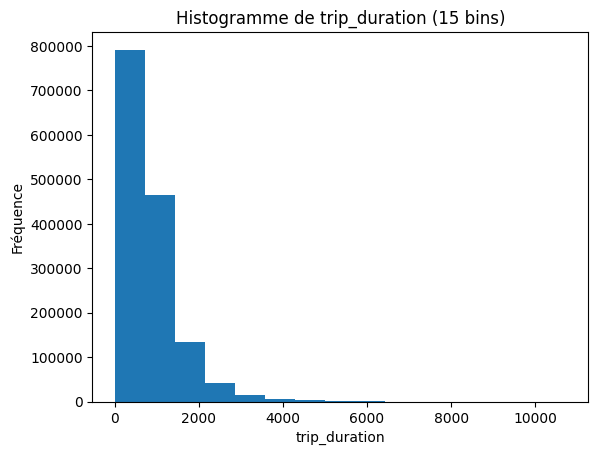

In [34]:
import numpy as np
import matplotlib.pyplot as plt

nbins = 15
bins = np.linspace(mn, mx, nbins + 1).tolist()

bin_edges, counts = (
    df_train.select(col)
      .where(F.col(col).isNotNull())
      .rdd.map(lambda r: float(r[0]))
      .histogram(bins)
)

widths = np.diff(bin_edges)
plt.figure()
plt.bar(bin_edges[:-1], counts, width=widths, align="edge")
plt.title(f"Histogramme de {col} ({nbins} bins)")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()


In [35]:
df_train = df_train.withColumn("log_trip_duration", F.log1p("trip_duration"))


In [36]:
df_train.show(5)

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_month|pickup_hour|pickup_dow|is_weekend| log_trip_duration|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+
|id2875421|        2|2016-03-14 17:24:55|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|           3|         17|         2|         0|6.1224928095143865|
|id2377394|        1|2016-06-12 00:43:35|              1|-73.9804153

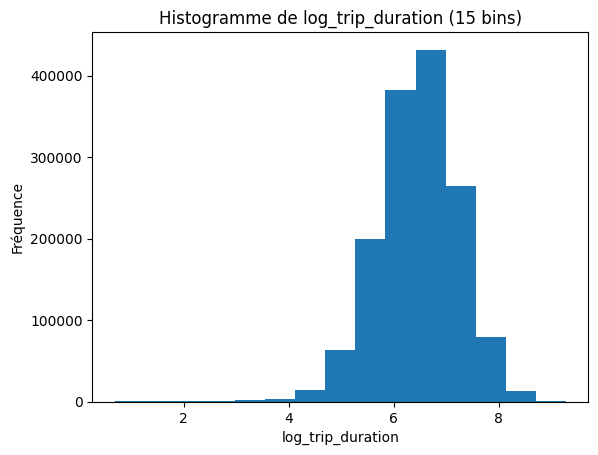

In [37]:
col = "log_trip_duration"

row = (
    df_train.where(F.col(col).isNotNull())
      .select(F.min(col).alias("min"), F.max(col).alias("max"))
      .first()
)

mn, mx = float(row["min"]), float(row["max"])

nbins = 15
bins = np.linspace(mn, mx, nbins + 1).tolist()

bin_edges, counts = (
    df_train.select(col)
      .where(F.col(col).isNotNull())
      .rdd.map(lambda r: float(r[0]))
      .histogram(bins)
)

widths = np.diff(bin_edges)
plt.figure()
plt.bar(bin_edges[:-1], counts, width=widths, align="edge")
plt.title(f"Histogramme de {col} ({nbins} bins)")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()



In [38]:
df_train.columns, len(df_train.columns)

(['id',
  'vendor_id',
  'pickup_datetime',
  'passenger_count',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'store_and_fwd_flag',
  'trip_duration',
  'pickup_month',
  'pickup_hour',
  'pickup_dow',
  'is_weekend',
  'log_trip_duration'],
 15)

In [39]:
df_test.columns, len(df_test.columns)

(['id',
  'vendor_id',
  'pickup_datetime',
  'passenger_count',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'store_and_fwd_flag',
  'pickup_month',
  'pickup_hour',
  'pickup_dow',
  'is_weekend'],
 13)

In [40]:
from pyspark.sql import functions as F

R = 6371.0  # rayon Terre en km

df_train = (df_train
  .withColumn("pickup_lat_rad", F.radians(F.col("pickup_latitude")))
  .withColumn("pickup_lon_rad", F.radians(F.col("pickup_longitude")))
  .withColumn("dropoff_lat_rad", F.radians(F.col("dropoff_latitude")))
  .withColumn("dropoff_lon_rad", F.radians(F.col("dropoff_longitude")))
  .withColumn("dlat", F.col("dropoff_lat_rad") - F.col("pickup_lat_rad"))
  .withColumn("dlon", F.col("dropoff_lon_rad") - F.col("pickup_lon_rad"))
  .withColumn("a", F.pow(F.sin(F.col("dlat")/2),2) +
                   F.cos(F.col("pickup_lat_rad"))*F.cos(F.col("dropoff_lat_rad"))*
                   F.pow(F.sin(F.col("dlon")/2),2))
  .withColumn("c", 2*F.asin(F.sqrt(F.col("a"))))
  .withColumn("distance_km", F.lit(R)*F.col("c"))
  .drop("pickup_lat_rad","pickup_lon_rad","dropoff_lat_rad","dropoff_lon_rad","dlat","dlon","a","c")
)

df_test = (df_test
  .withColumn("pickup_lat_rad", F.radians(F.col("pickup_latitude")))
  .withColumn("pickup_lon_rad", F.radians(F.col("pickup_longitude")))
  .withColumn("dropoff_lat_rad", F.radians(F.col("dropoff_latitude")))
  .withColumn("dropoff_lon_rad", F.radians(F.col("dropoff_longitude")))
  .withColumn("dlat", F.col("dropoff_lat_rad") - F.col("pickup_lat_rad"))
  .withColumn("dlon", F.col("dropoff_lon_rad") - F.col("pickup_lon_rad"))
  .withColumn("a", F.pow(F.sin(F.col("dlat")/2),2) +
                   F.cos(F.col("pickup_lat_rad"))*F.cos(F.col("dropoff_lat_rad"))*
                   F.pow(F.sin(F.col("dlon")/2),2))
  .withColumn("c", 2*F.asin(F.sqrt(F.col("a"))))
  .withColumn("distance_km", F.lit(R)*F.col("c"))
  .drop("pickup_lat_rad","pickup_lon_rad","dropoff_lat_rad","dropoff_lon_rad","dlat","dlon","a","c")
)


In [41]:
df_train.show(5)

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_month|pickup_hour|pickup_dow|is_weekend| log_trip_duration|       distance_km|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+------------------+
|id2875421|        2|2016-03-14 17:24:55|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|           3|         17|         2|         0|6.1224928095143865|1.4985207796

In [42]:
df_test.show(5)

+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|pickup_month|pickup_hour|pickup_dow|is_weekend|       distance_km|
+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+------------------+
|id3004672|        1|2016-06-30 23:59:58|              1|-73.98812866210938|40.73202896118164|-73.99017333984375| 40.75667953491211|                 N|           6|         23|         5|         0| 2.746425820747344|
|id3505355|        1|2016-06-30 23:59:53|              1|-73.96420288085938|40.67999267578125|-73.95980834960938| 40.65540313720

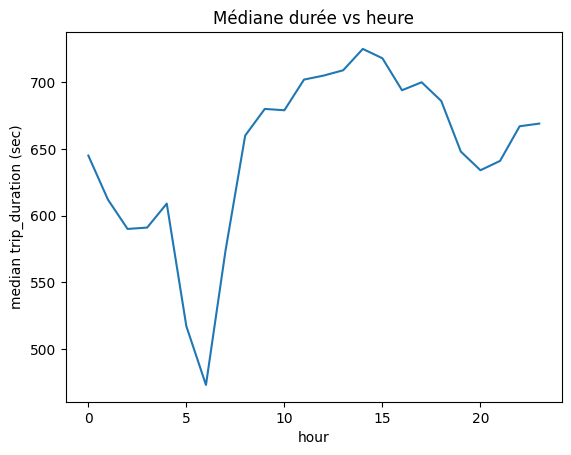

In [43]:
hour_stats = (df_train
    .groupBy("pickup_hour")
    .agg(
        F.count("*").alias("n"),
        F.avg("trip_duration").alias("mean_duration"),
        F.expr("percentile_approx(trip_duration, 0.5)").alias("median_duration")
    )
    .orderBy("pickup_hour")
    .toPandas()
)

plt.figure()
plt.plot(hour_stats["pickup_hour"], hour_stats["median_duration"])
plt.xlabel("hour")
plt.ylabel("median trip_duration (sec)")
plt.title("Médiane durée vs heure")
plt.show()


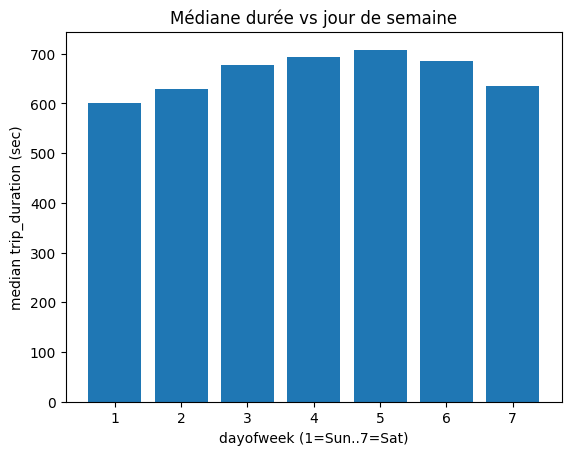

In [44]:
dow_stats = (df_train
    .groupBy("pickup_dow")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(trip_duration, 0.5)").alias("median_duration")
    )
    .orderBy("pickup_dow")
    .toPandas()
)

plt.figure()
plt.bar(dow_stats["pickup_dow"], dow_stats["median_duration"])
plt.xlabel("dayofweek (1=Sun..7=Sat)")
plt.ylabel("median trip_duration (sec)")
plt.title("Médiane durée vs jour de semaine")
plt.show()


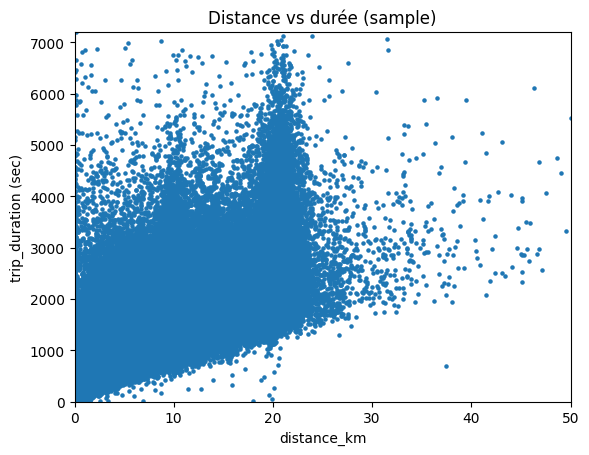

In [45]:
sample_pd = (df_train
    .select("distance_km", "trip_duration")
    .sample(False, 0.5, seed=42) 
    .toPandas()
)

plt.figure()
plt.scatter(sample_pd["distance_km"], sample_pd["trip_duration"], s=5)
plt.xlabel("distance_km")
plt.ylabel("trip_duration (sec)")
plt.title("Distance vs durée (sample)")
plt.ylim(0, 2*3600)     # zoom 3h
plt.xlim(0, 50)       # zoom 50km
plt.show()


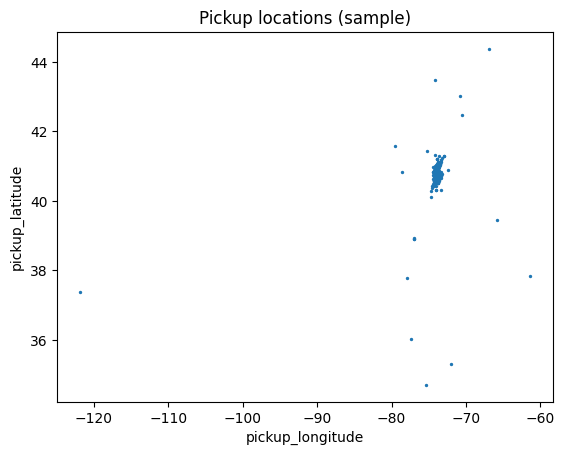

In [46]:
geo_pd = (df_train
    .select("pickup_longitude", "pickup_latitude")
    .sample(False, 0.5, seed=42)
    .toPandas()
)

plt.figure()
plt.scatter(geo_pd["pickup_longitude"], geo_pd["pickup_latitude"], s=2)
plt.xlabel("pickup_longitude")
plt.ylabel("pickup_latitude")
plt.title("Pickup locations (sample)")
plt.show()


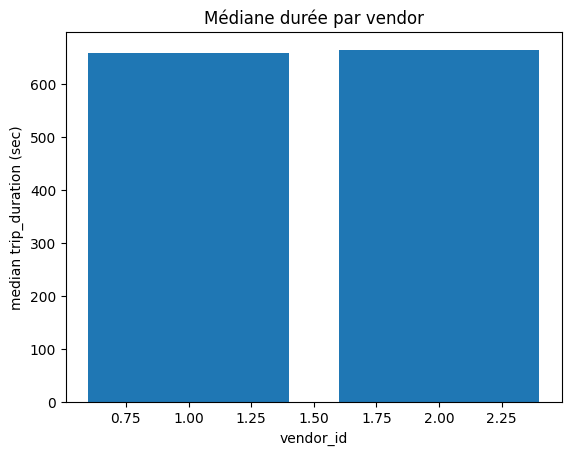

In [47]:
vendor_stats = (df_train
    .groupBy("vendor_id")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(trip_duration, 0.5)").alias("median_duration")
    )
    .orderBy("vendor_id")
    .toPandas()
)

plt.figure()
plt.bar(vendor_stats["vendor_id"], vendor_stats["median_duration"])
plt.xlabel("vendor_id")
plt.ylabel("median trip_duration (sec)")
plt.title("Médiane durée par vendor")
plt.show()


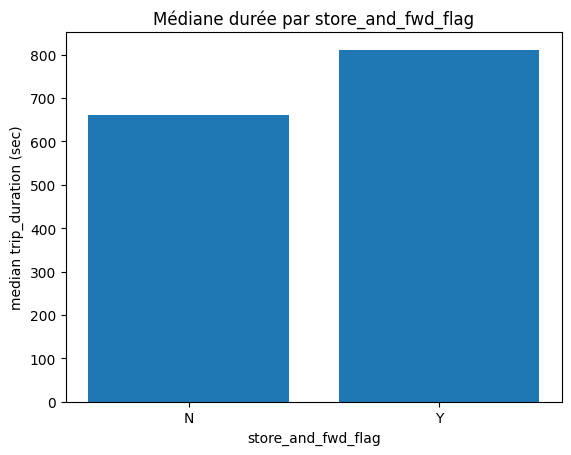

In [48]:
flag_stats = (df_train
    .groupBy("store_and_fwd_flag")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(trip_duration, 0.5)").alias("median_duration")
    )
    .orderBy("store_and_fwd_flag")
    .toPandas()
)

plt.figure()
plt.bar(flag_stats["store_and_fwd_flag"], flag_stats["median_duration"])
plt.xlabel("store_and_fwd_flag")
plt.ylabel("median trip_duration (sec)")
plt.title("Médiane durée par store_and_fwd_flag")
plt.show()


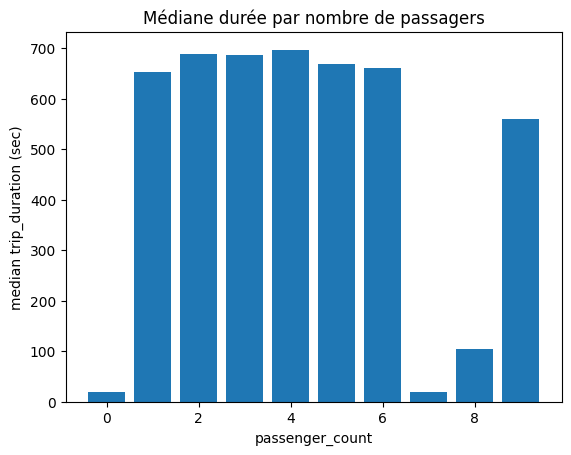

In [49]:
vendor_stats = (df_train
    .groupBy("passenger_count")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(trip_duration, 0.5)").alias("median_duration")
    )
    .orderBy("passenger_count")
    .toPandas()
)

plt.figure()
plt.bar(vendor_stats["passenger_count"], vendor_stats["median_duration"])
plt.xlabel("passenger_count")
plt.ylabel("median trip_duration (sec)")
plt.title("Médiane durée par nombre de passagers")
plt.show()


In [50]:
df_train.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'trip_duration',
 'pickup_month',
 'pickup_hour',
 'pickup_dow',
 'is_weekend',
 'log_trip_duration',
 'distance_km']

In [51]:
df_test.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'pickup_month',
 'pickup_hour',
 'pickup_dow',
 'is_weekend',
 'distance_km']

In [52]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="store_and_fwd_flag", outputCol="store_and_fwd_flag_index")

indexer_model = indexer.fit(df_train)

df_train = indexer_model.transform(df_train)
df_test  = indexer_model.transform(df_test)

In [53]:
df_train.show(5)

+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+------------------+------------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|   pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|trip_duration|pickup_month|pickup_hour|pickup_dow|is_weekend| log_trip_duration|       distance_km|store_and_fwd_flag_index|
+---------+---------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+------------+-----------+----------+----------+------------------+------------------+------------------------+
|id2875421|        2|2016-03-14 17:24:55|              1| -73.9821548461914| 40.76793670654297|-73.96463012695312|40.765602111816406|                 N|          455|   

In [54]:
df_test.show(5)

+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+------------------+------------------------+
|       id|vendor_id|    pickup_datetime|passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|store_and_fwd_flag|pickup_month|pickup_hour|pickup_dow|is_weekend|       distance_km|store_and_fwd_flag_index|
+---------+---------+-------------------+---------------+------------------+-----------------+------------------+------------------+------------------+------------+-----------+----------+----------+------------------+------------------------+
|id3004672|        1|2016-06-30 23:59:58|              1|-73.98812866210938|40.73202896118164|-73.99017333984375| 40.75667953491211|                 N|           6|         23|         5|         0| 2.746425820747344|                     0.0|
|id3505355|        1|2016-06

In [55]:
df_train.columns

['id',
 'vendor_id',
 'pickup_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'trip_duration',
 'pickup_month',
 'pickup_hour',
 'pickup_dow',
 'is_weekend',
 'log_trip_duration',
 'distance_km',
 'store_and_fwd_flag_index']

In [56]:
df_train = df_train.select('id',
    'vendor_id',
    'passenger_count',
    'pickup_month',
    'pickup_hour',
    'pickup_dow',
    'is_weekend',
    'distance_km',
    'store_and_fwd_flag_index',
    'log_trip_duration',
    'trip_duration'
)

df_test = df_test.select('id',
    'vendor_id',
    'passenger_count',
    'pickup_month',
    'pickup_hour',
    'pickup_dow',
    'is_weekend',
    'distance_km',
    'store_and_fwd_flag_index'
)


In [57]:
df_train.show(5)

+---------+---------+---------------+------------+-----------+----------+----------+------------------+------------------------+------------------+-------------+
|       id|vendor_id|passenger_count|pickup_month|pickup_hour|pickup_dow|is_weekend|       distance_km|store_and_fwd_flag_index| log_trip_duration|trip_duration|
+---------+---------+---------------+------------+-----------+----------+----------+------------------+------------------------+------------------+-------------+
|id2875421|        2|              1|           3|         17|         2|         0|1.4985207796469109|                     0.0|6.1224928095143865|          455|
|id2377394|        1|              1|           6|          0|         1|         1|1.8055071687958897|                     0.0| 6.498282149476434|          663|
|id3858529|        2|              1|           1|         11|         3|         0| 6.385098495252496|                     0.0| 7.661527081358517|         2124|
|id3504673|        2|       

In [58]:
df_test.show(5)

+---------+---------+---------------+------------+-----------+----------+----------+------------------+------------------------+
|       id|vendor_id|passenger_count|pickup_month|pickup_hour|pickup_dow|is_weekend|       distance_km|store_and_fwd_flag_index|
+---------+---------+---------------+------------+-----------+----------+----------+------------------+------------------------+
|id3004672|        1|              1|           6|         23|         5|         0| 2.746425820747344|                     0.0|
|id3505355|        1|              1|           6|         23|         5|         0|2.7592389329009714|                     0.0|
|id1217141|        1|              1|           6|         23|         5|         0|1.3061553897970135|                     0.0|
|id2150126|        2|              1|           6|         23|         5|         0|5.2690877407288035|                     0.0|
|id1598245|        1|              1|           6|         23|         5|         0|0.96084182713

In [ ]:
df_train.coalesce(1).write.csv("data/cleaned/df_train.csv", header=True, mode="overwrite")
df_test.coalesce(1).write.csv("data/cleaned/df_test.csv", header=True, mode="overwrite")

In [ ]:
# df_train = df_train.toPandas()
# df_test = df_test.toPandas()
# df_train.to_csv("data/cleaned/df_train.csv", index=False, encoding='utf-8')
# df_test.to_csv("data/cleaned/df_test.csv", index=False, encoding='utf-8')